# Explicabilidad: SHAP para XGBoost + ROS refinado

Este notebook explica el modelo final del proyecto —`xgboost_refinado.joblib`,
con el umbral y las bandas de riesgo definidos en `06_refinamiento_modelo.ipynb`—
mediante SHAP (SHapley Additive exPlanations). Cubre la **importancia global**:
qué variables influyen más, en promedio, sobre las predicciones del modelo,
calculada sobre el conjunto de validación. Este notebook no abre el conjunto
de prueba. Las explicaciones locales SHAP para casos concretos (verdadero
positivo, falso positivo, verdadero negativo) se calculan una única vez sobre
el conjunto de prueba en `08_evaluacion_final_test.ipynb`, junto con las
métricas finales del modelo.

**Aclaración importante**: SHAP explica las **asociaciones que el modelo
aprendió**, no relaciones causales. Que una variable tenga un valor SHAP
alto significa que el modelo la usó para esa predicción, no que esa
variable *cause* el abandono.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import shap

from sklearn.metrics import accuracy_score, precision_score, recall_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Versión de shap:", shap.__version__)

Versión de shap: 0.52.0


## 1. Carga de artefactos

Se carga el modelo refinado (no el baseline), el umbral de decisión, y los
mismos splits preprocesados usados en el resto del proyecto.

In [2]:
ruta_artefactos = Path("../artifacts")
ruta_modelos = Path("../models")
ruta_figuras = Path("../figures")

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")
X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
y_train = artefactos["y_train"]
y_val = artefactos["y_val"]
nombres_variables = artefactos["nombres_variables"]

modelo = joblib.load(ruta_modelos / "xgboost_refinado.joblib")

with open(ruta_modelos / "config_umbral.json", encoding="utf-8") as f:
    config_umbral = json.load(f)

umbral_decision = config_umbral["umbral_decision"]

print("Modelo cargado: xgboost_refinado.joblib")
print("Umbral de decisión:", umbral_decision)
print("Variables (58):", len(nombres_variables))

Modelo cargado: xgboost_refinado.joblib
Umbral de decisión: 0.56
Variables (58): 58


## 2. Nombres de variables legibles

`nombres_variables` trae los prefijos técnicos del `ColumnTransformer`
(`numericas__` / `categoricas__`). Se construye un mapeo a nombres
legibles para que los gráficos de SHAP se entiendan sin conocer el
pipeline de preprocesamiento.

In [3]:
import sys

sys.path.insert(0, str(Path("..").resolve()))
from backend.schema import readable_name

nombres_legibles = [readable_name(n) for n in nombres_variables]

X_train_df = pd.DataFrame(X_train, columns=nombres_legibles)
X_val_df = pd.DataFrame(X_val, columns=nombres_legibles)

print("Ejemplos de nombres legibles:")
for original, legible in list(zip(nombres_variables, nombres_legibles))[:5]:
    print(f"  {original}  ->  {legible}")

Ejemplos de nombres legibles:
  numericas__age  ->  age
  numericas__tenure_months  ->  tenure_months
  numericas__monthly_logins  ->  monthly_logins
  numericas__weekly_active_days  ->  weekly_active_days
  numericas__avg_session_time  ->  avg_session_time


## 3. Explainer de SHAP

Se intentó `TreeExplainer` en espacio de probabilidad (con un fondo de 100 filas de entrenamiento), para que los valores se leyeran directamente como cambios de probabilidad. Ese modo **falló** con `NotImplementedError: Categorical split is not yet supported`: XGBoost 3.x puede construir árboles con splits categóricos nativos, y el modo `interventional` de shap 0.52 todavía no los soporta. El notebook detecta esto automáticamente y usa como respaldo el **espacio de margen (log-odds)**, que sí es compatible.

Esto cambia cómo se leen los números: un valor SHAP de +1,0 no significa "+1,0 puntos de probabilidad", sino que aumenta el log-odds del modelo en 1,0 — empuja la predicción hacia churn, y cuanto mayor el valor absoluto, más fuerte el empuje. Para interpretar cada caso local alcanza con comparar las magnitudes entre variables (cuál pesó más) y el signo (empuja hacia churn o hacia permanencia); no se necesita convertir a puntos de probabilidad para que la explicación sea útil.

In [4]:
fondo = shap.sample(X_train_df, 100, random_state=RANDOM_STATE)

espacio_probabilidad = True
try:
    explainer = shap.TreeExplainer(
        modelo,
        data=fondo,
        model_output="probability",
        feature_perturbation="interventional",
    )
    # Prueba rápida para confirmar que el modo probabilidad funciona
    _ = explainer(X_val_df.iloc[:5])
    print("Explainer creado en espacio de PROBABILIDAD.")
except Exception as error:
    print(f"Modo probabilidad falló ({error!r}); usando espacio de margen (log-odds) como respaldo.")
    espacio_probabilidad = False
    explainer = shap.TreeExplainer(modelo)

Modo probabilidad falló (NotImplementedError('Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.')); usando espacio de margen (log-odds) como respaldo.

## 4. Importancia global

Se calculan los valores SHAP sobre el conjunto de validación completo
(1.500 casos) y se grafican la importancia global (barras, promedio del
valor absoluto) y el resumen tipo *beeswarm* (dirección y magnitud del
efecto de cada variable).

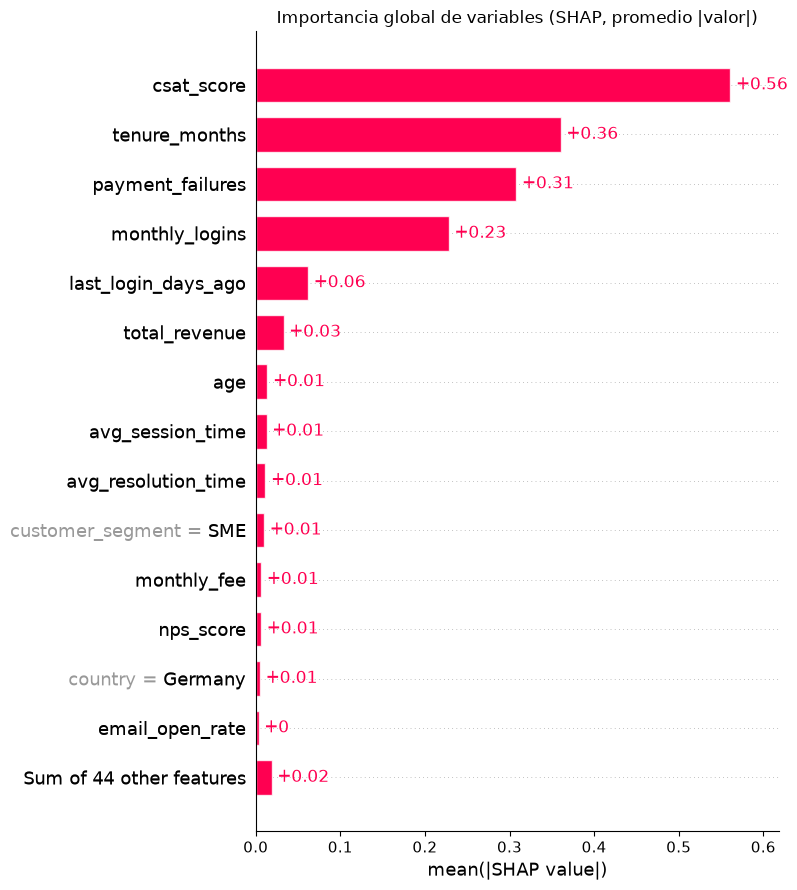

In [5]:
explicacion_val = explainer(X_val_df)

fig = plt.figure(figsize=(9, 7))
shap.plots.bar(explicacion_val, max_display=15, show=False)
plt.title("Importancia global de variables (SHAP, promedio |valor|)")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_01_shap_importancia_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

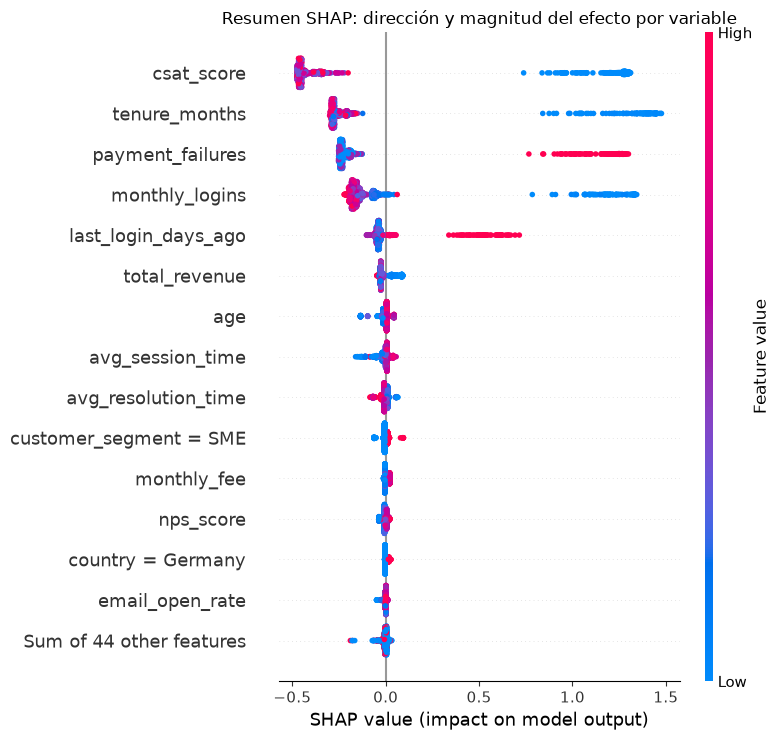

In [6]:
fig = plt.figure(figsize=(9, 8))
shap.plots.beeswarm(explicacion_val, max_display=15, show=False)
plt.title("Resumen SHAP: dirección y magnitud del efecto por variable")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_02_shap_resumen_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
importancia_global = pd.DataFrame({
    "variable": nombres_legibles,
    "importancia_media_abs": np.abs(explicacion_val.values).mean(axis=0),
}).sort_values("importancia_media_abs", ascending=False).reset_index(drop=True)

importancia_global.to_csv(ruta_modelos / "shap_importancia_global.csv", index=False)
importancia_global.head(15)

,variable,importancia_media_abs
0,csat_score,0.561049
1,tenure_months,0.360554
2,payment_failures,0.308113
3,monthly_logins,0.228238
4,last_login_days_ago,0.061951
5,total_revenue,0.032903
6,age,0.013872
7,avg_session_time,0.012855
8,avg_resolution_time,0.011542
9,customer_segment = SME,0.009965


## 5. Qué se guarda para el prototipo

No se guarda (ni se serializa) el objeto `explainer`: construir un
`TreeExplainer` desde un modelo de árboles ya entrenado es una operación
barata (lee la estructura de árboles), y calcular SHAP para una sola fila
en el momento de la predicción toma milisegundos. El backend de la
aplicación construye el explainer una sola vez al iniciar (cacheado) y
calcula la explicación local en cada solicitud. Lo único que se persiste
aquí es `models/shap_importancia_global.csv`, para que la vista global de
la aplicación no tenga que recalcular SHAP sobre un conjunto de fondo cada
vez que se abre.

En la etapa de integración se evaluará construir y cachear el explainer al iniciar la aplicación. La latencia de la explicación individual deberá medirse durante las pruebas del prototipo.

## 6. Conclusiones

La importancia global coincide, en gran medida, con lo que ya había aparecido en el análisis exploratorio (sección 4.1.6): `csat_score`, `tenure_months`, `payment_failures` y `monthly_logins` son, en ese orden, las cuatro variables con mayor peso en las predicciones del modelo — las mismas cuatro que mostraron las diferencias de medias (Cohen's d) más grandes entre clientes que permanecen y abandonan. Esto es una señal de consistencia entre el análisis descriptivo inicial y lo que el modelo terminó aprendiendo: muestra consistencia con el análisis exploratorio, aunque no permite descartar completamente patrones espurios o interacciones difíciles de interpretar.

Esta importancia global se calculó íntegramente sobre el conjunto de validación, sin abrir el conjunto de prueba. Las explicaciones locales para casos individuales (verdadero positivo, falso positivo, verdadero negativo), que ilustran cómo se combinan estas señales en la práctica para un cliente concreto, se calculan en `08_evaluacion_final_test.ipynb`, junto con las métricas finales del modelo sobre prueba.

**Aclaración final**: estas explicaciones muestran qué variables *usó el modelo* para cada predicción — es decir, asociaciones que aprendió de los datos de entrenamiento. No son evidencia de que, por ejemplo, mejorar artificialmente el `csat_score` de un cliente vaya a *causar* que deje de abandonar; podría ser que ambas cosas respondan a una causa común (por ejemplo, un mal soporte técnico que afecta la satisfacción y el uso al mismo tiempo). Para decisiones de retención, estas explicaciones sirven para priorizar y entender el riesgo detectado por el modelo, no como receta causal.